# CMAPSS - the RUL model, full fleet

**Arkon Manufacturing AI | Module: Time Series | Department: Engine Testing**

One model over all four subsets: 160,359 training rows from 709 engines, tested
on 707 engines flying six regimes with two fault modes.

**The benchmark task is not the row-level error.** It is one prediction per engine
at its last recorded cycle, because that is the moment a maintenance decision
would be made. Both are reported and they are different numbers.

Nothing here is imported from `cmapss_full_fleet.py`, and this notebook writes
the artifacts `events/make_events_cmapss.py` turns into Arkon risk events.

## 1. Imports and configuration

The shared helpers live in `notebooks/utils`. This cell puts that directory on the path.

In [1]:
import sys
from pathlib import Path

# Add notebooks/utils to path (works on Mac, Windows, Linux)
_nb_root = Path('..').resolve()
if str(_nb_root) not in sys.path:
    sys.path.insert(0, str(_nb_root))

from utils.arkon_utils import save_figure, get_mlflow_uri

print('arkon_utils loaded')

arkon_utils loaded


The libraries, including XGBoost and MLflow.

In [2]:
import json
import time

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import xgboost
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

ASSETS = 'timeseries'
PROC_DIR = Path('../../data/01_cmapss/processed')
CKPT_DIR = Path('../../models/checkpoints/cmapss')
CKPT_DIR.mkdir(parents=True, exist_ok=True)

# The window notebook 02 built the temporal features over, repeated here so the
# suffixes this notebook looks for cannot silently disagree with the columns
ALL_SENSORS = [f's{i}' for i in range(1, 22)]
WINDOW = 20

print(f'python  {sys.version.split()[0]}')
print(f'pandas  {pd.__version__}')
print(f'xgboost {xgboost.__version__}')
print(f'mlflow  {mlflow.__version__}')

python  3.12.10
pandas  2.3.3
xgboost 3.2.0
mlflow  3.13.0


## 2. The reference, read before anything is trained

Whatever the last run recorded. This notebook overwrites that file at the end, so
it is loaded now while it still describes the previous run, and compared against
in section 11. A number that moves is then reported rather than quietly
overwritten.

In [3]:
META_PATH = CKPT_DIR / 'cmapss_full_fleet_meta.json'
reference = json.loads(META_PATH.read_text(encoding='utf-8')) if META_PATH.exists() else None

if reference:
    print('reference metrics found, recorded by the previous run')
    print(f"  xgboost last cycle RMSE {reference['results']['xgboost']['last_cycle']['rmse']:.3f}"
          f"   over {reference['results']['xgboost']['last_cycle']['n']} engines")
    print(f"  trained on {reference['trained_on']}, {reference['train_rows']:,} rows, "
          f"{len(reference['features'])} features")
else:
    print('no reference yet: this is the first run')

reference metrics found, recorded by the previous run
  xgboost last cycle RMSE 11.012   over 707 engines
  trained on ['FD001', 'FD002', 'FD003', 'FD004'], 160,359 rows, 70 features


## 3. Load the processed fleet

Written by `02_cmapss_preprocessing.ipynb`: RUL labels, four sensors dropped, per-regime standardisation and the 20-cycle temporal features.

In [4]:
t0 = time.time()
train = pd.read_csv(PROC_DIR / 'train_full_fleet_processed.csv')
test = pd.read_csv(PROC_DIR / 'test_full_fleet_processed.csv')
prep = joblib.load(PROC_DIR / 'preprocessing_full_fleet.pkl')
feature_cols = prep['feature_cols']
keep_sensors = prep['keep_sensors']

print(f'loaded in {time.time() - t0:.1f}s')
print(f'train {len(train):>8,} rows   {train.unit_uid.nunique():>3} engines')
print(f'test  {len(test):>8,} rows   {test.unit_uid.nunique():>3} engines')
print(f'features {len(feature_cols)}   RUL capped at {prep["rul_cap"]}')

loaded in 5.5s
train  160,359 rows   709 engines
test   104,897 rows   707 engines
features 70   RUL capped at 125


The feature matrices themselves, and the mask that marks each engine's last cycle.

In [5]:
X_train = train[feature_cols].to_numpy()
y_train = train.RUL.to_numpy()
X_test = test[feature_cols].to_numpy()
y_test = test.RUL.to_numpy()
last_mask = test.is_last_cycle.to_numpy()

print(f'X_train {X_train.shape}   X_test {X_test.shape}')
print(f'target range {y_train.min():.0f} to {y_train.max():.0f} cycles')
print(f'{last_mask.sum()} last-cycle rows, one per test engine')

X_train (160359, 70)   X_test (104897, 70)
target range 0 to 125 cycles
707 last-cycle rows, one per test engine


## 4. How the model is scored

Three views of the same predictions. `all_rows` is every row of every test
engine, which is the number most CMAPSS write-ups report. `last_cycle` is one
prediction per engine at its final cycle, which is the benchmark task.
`per_subset` keeps the easy and the hard subsets from averaging into silence.

In [6]:
def score(y_true, y_pred, label=None):
    out = {'rmse': float(np.sqrt(mean_squared_error(y_true, y_pred))),
           'mae': float(mean_absolute_error(y_true, y_pred)),
           'r2': float(r2_score(y_true, y_pred)),
           'n': int(len(y_true))}
    if label:
        print(f'  {label:<28} RMSE {out["rmse"]:7.3f}   MAE {out["mae"]:7.3f}   '
              f'R2 {out["r2"]:7.4f}   n={out["n"]:,}')
    return out


def score_all(pred):
    out = {'all_rows': score(y_test, pred, 'all test rows'),
           'last_cycle': score(y_test[last_mask], pred[last_mask], 'last cycle per unit'),
           'per_subset': {}}
    for name in sorted(test.dataset.unique()):
        m = (test.dataset == name).to_numpy()
        out['per_subset'][name] = {
            'all_rows': score(y_test[m], pred[m]),
            'last_cycle': score(y_test[m & last_mask], pred[m & last_mask]),
        }
    return out


print('scoring helpers ready')

scoring helpers ready


## 5. Baseline: linear regression

Trained on exactly the same 70 features, to answer one question: how much of the result comes from the feature set rather than from the model class.

In [7]:
mlflow.set_tracking_uri(get_mlflow_uri())
mlflow.set_experiment('arkon-timeseries-cmapss')

results, models = {}, {}
t0 = time.time()
models['linear_regression'] = LinearRegression().fit(X_train, y_train)
lin_time = time.time() - t0
print(f'linear regression, trained in {lin_time:.1f}s')
results['linear_regression'] = score_all(models['linear_regression'].predict(X_test))

linear regression, trained in 0.7s
  all test rows                RMSE  14.356   MAE  11.035   R2  0.7144   n=104,897
  last cycle per unit          RMSE  16.411   MAE  13.398   R2  0.8480   n=707


## 6. The deployed configuration

Hyperparameters written out here rather than imported, so the notebook stands on
its own. `hist` is the histogram tree method, which is what makes 600 trees over
160,000 rows a half-minute job rather than an afternoon.

In [8]:
XGB_PARAMS = {
    'n_estimators': 600,
    'max_depth': 8,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'n_jobs': -1,
    'tree_method': 'hist',
}

t0 = time.time()
models['xgboost'] = XGBRegressor(**XGB_PARAMS).fit(X_train, y_train)
xgb_time = time.time() - t0
pred_xgb = models['xgboost'].predict(X_test)
print(f'xgboost, trained in {xgb_time:.1f}s')
results['xgboost'] = score_all(pred_xgb)

xgboost, trained in 32.6s
  all test rows                RMSE  10.051   MAE   6.131   R2  0.8600   n=104,897
  last cycle per unit          RMSE  11.012   MAE   7.617   R2  0.9315   n=707


## 7. Per subset, and the benchmark task

FD001 and FD003 fly one operating regime; FD002 and FD004 fly six, and FD003 and
FD004 carry two fault modes. If one model over a mixed fleet is a defensible
idea, the hardest subset must not collapse.

In [9]:
per_subset = pd.DataFrame({
    name: {'engines': v['last_cycle']['n'],
           'all_rows_rmse': round(v['all_rows']['rmse'], 3),
           'last_cycle_rmse': round(v['last_cycle']['rmse'], 3)}
    for name, v in results['xgboost']['per_subset'].items()
}).T
print(per_subset.to_string())

       engines  all_rows_rmse  last_cycle_rmse
FD001    100.0          9.501            9.692
FD002    259.0         10.633           11.071
FD003    100.0          8.422           10.918
FD004    248.0         10.325           11.479


The same comparison drawn: row-level against benchmark, per subset.

  ✓ Saved → assets\timeseries\cmapss_model_fleet_performance.png


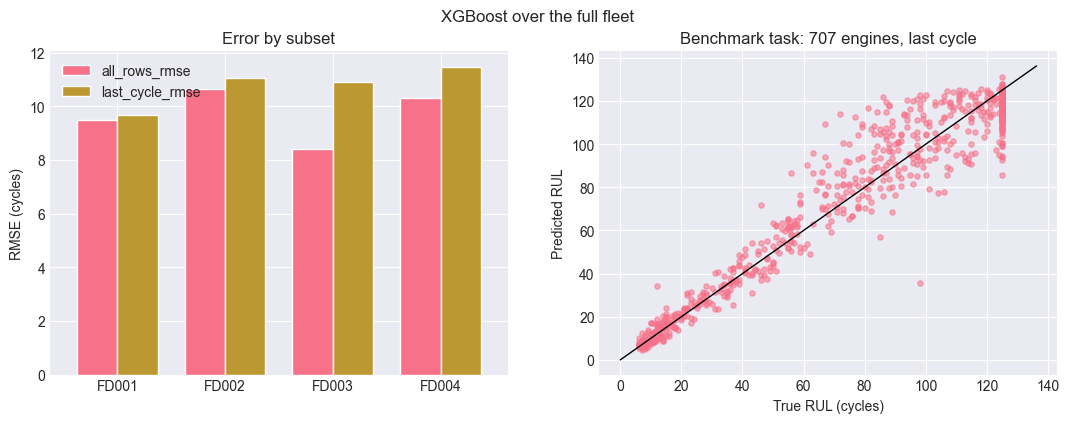

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
per_subset[['all_rows_rmse', 'last_cycle_rmse']].plot(kind='bar', ax=axes[0],
                                                      edgecolor='white', width=0.75)
axes[0].set_ylabel('RMSE (cycles)')
axes[0].set_title('Error by subset')
axes[0].tick_params(axis='x', rotation=0)

axes[1].scatter(y_test[last_mask], pred_xgb[last_mask], s=14, alpha=0.55)
lims = [0, max(y_test[last_mask].max(), pred_xgb[last_mask].max()) + 5]
axes[1].plot(lims, lims, linewidth=1, color='black')
axes[1].set_xlabel('True RUL (cycles)')
axes[1].set_ylabel('Predicted RUL')
axes[1].set_title(f'Benchmark task: {int(last_mask.sum())} engines, last cycle')
fig.suptitle('XGBoost over the full fleet')
save_figure(fig, 'cmapss_model_fleet_performance', subfolder=ASSETS)
plt.show()

## 8. Two ablations

The headline number says the model works. It does not say what made it work, and
the two candidate answers cost very different amounts to obtain.

**Did the extra data help?** Both arms use the same reduced hyperparameters and
preprocessing and are scored on the FD001 test set, so the only difference left
is what the model was trained on.

In [11]:
baseline_params = {**XGB_PARAMS, 'n_estimators': 300, 'max_depth': 6}
fd001_train = (train.dataset == 'FD001').to_numpy()
fd001_test = (test.dataset == 'FD001').to_numpy()

print('=== data ablation: FD001 only against the full fleet, scored on FD001 ===')
ablation = {'hyperparameters': baseline_params}
for arm, mask in [('trained_on_FD001_only', fd001_train),
                  ('trained_on_full_fleet', np.ones(len(train), dtype=bool))]:
    m = XGBRegressor(**baseline_params).fit(X_train[mask], y_train[mask])
    ablation[arm] = {
        'train_rows': int(mask.sum()),
        'all_rows': score(y_test[fd001_test], m.predict(X_test[fd001_test]),
                          f'{arm} -> all rows'),
        'last_cycle': score(y_test[fd001_test & last_mask],
                            m.predict(X_test[fd001_test & last_mask]),
                            f'{arm} -> last cycle'),
    }
delta = (ablation['trained_on_FD001_only']['all_rows']['rmse']
         - ablation['trained_on_full_fleet']['all_rows']['rmse'])
ablation['fd001_all_rows_rmse_delta'] = delta
print(f'  eight times the training data is worth {delta:+.3f} RMSE on FD001')

=== data ablation: FD001 only against the full fleet, scored on FD001 ===


  trained_on_FD001_only -> all rows RMSE  10.854   MAE   7.371   R2  0.8451   n=13,096
  trained_on_FD001_only -> last cycle RMSE  10.957   MAE   7.966   R2  0.9252   n=100


  trained_on_full_fleet -> all rows RMSE  10.080   MAE   6.713   R2  0.8664   n=13,096
  trained_on_full_fleet -> last cycle RMSE  10.041   MAE   7.098   R2  0.9372   n=100
  eight times the training data is worth +0.774 RMSE on FD001


**Did treating this as a time series pay?** Snapshot features alone reduce the module to tabular regression on time-indexed rows, with the raw cycle counter as its only view of time. This cell removes the temporal block and re-scores.

In [12]:
print('=== feature ablation: what the temporal window is worth ===')
idx = {c: i for i, c in enumerate(feature_cols)}
arms = {
    'sensors_only': [idx[c] for c in keep_sensors + ['regime_code']],
    'sensors_plus_cycle': [idx[c] for c in keep_sensors + ['cycle', 'regime_code']],
    'with_temporal_features': list(range(len(feature_cols))),
}
feature_ablation = {'window': WINDOW, 'hyperparameters': baseline_params}
for arm, cols in arms.items():
    m = XGBRegressor(**baseline_params).fit(X_train[:, cols], y_train)
    feature_ablation[arm] = {
        'n_features': len(cols),
        'all_rows': score(y_test, m.predict(X_test[:, cols]), f'{arm} all rows'),
        'last_cycle': score(y_test[last_mask], m.predict(X_test[last_mask][:, cols]),
                            f'{arm} last cycle'),
    }
gain = (feature_ablation['sensors_plus_cycle']['last_cycle']['rmse']
        - feature_ablation['with_temporal_features']['last_cycle']['rmse'])
feature_ablation['temporal_rmse_gain_last_cycle'] = gain
print(f'  the 20-cycle window is worth {gain:+.3f} RMSE on the benchmark task')

=== feature ablation: what the temporal window is worth ===


  sensors_only all rows        RMSE  16.637   MAE  11.399   R2  0.6164   n=104,897
  sensors_only last cycle      RMSE  18.419   MAE  13.370   R2  0.8085   n=707


  sensors_plus_cycle all rows  RMSE  15.090   MAE   9.442   R2  0.6845   n=104,897
  sensors_plus_cycle last cycle RMSE  16.754   MAE  12.141   R2  0.8415   n=707


  with_temporal_features all rows RMSE  10.666   MAE   6.555   R2  0.8424   n=104,897
  with_temporal_features last cycle RMSE  11.430   MAE   7.893   R2  0.9262   n=707
  the 20-cycle window is worth +5.324 RMSE on the benchmark task


## 9. Which features the model actually uses

The importances, to see whether the temporal blocks earn the 51 columns they cost.

  ✓ Saved → assets\timeseries\cmapss_model_feature_importance.png


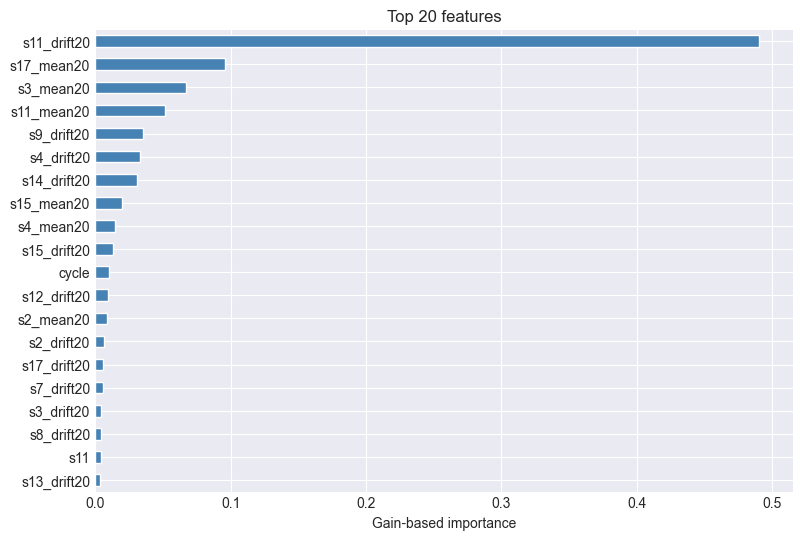

share of total importance
  raw sensor         2.6%
  cycle / regime     1.2%
  temporal          96.2%


In [13]:
importance = pd.Series(models['xgboost'].feature_importances_,
                       index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
importance.head(20)[::-1].plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Gain-based importance')
ax.set_title('Top 20 features')
save_figure(fig, 'cmapss_model_feature_importance', subfolder=ASSETS)
plt.show()

kinds = {'raw sensor': 0.0, 'cycle / regime': 0.0, 'temporal': 0.0}
for name, value in importance.items():
    if name in ('cycle', 'regime_code'):
        kinds['cycle / regime'] += value
    elif name.endswith(tuple(f'{k}{WINDOW}' for k in ('mean', 'std', 'drift'))):
        kinds['temporal'] += value
    else:
        kinds['raw sensor'] += value
print('share of total importance')
for k, v in kinds.items():
    print(f'  {k:<16} {v:6.1%}')

## 10. Write the artifacts

The two models, the metrics file, and the prediction table the risk-event adapter reads. The preprocessing artifact was written by notebook 02 and is not touched here.

In [14]:
meta = {
    'trained_on': sorted(train.dataset.unique().tolist()),
    'train_rows': int(len(train)),
    'test_rows': int(len(test)),
    'train_units': int(train.unit_uid.nunique()),
    'test_units': int(test.unit_uid.nunique()),
    'operating_regimes': int(train.regime.nunique()),
    'sensors_dropped': [s for s in ALL_SENSORS if s not in keep_sensors],
    'sensors_kept': keep_sensors,
    'features': feature_cols,
    'rul_cap': prep['rul_cap'],
    'normalisation': 'StandardScaler fit per operating regime on train only',
    'xgb_params': XGB_PARAMS,
    'window': WINDOW,
    'results': results,
    'ablation': ablation,
    'feature_ablation': feature_ablation,
}

for label, model in models.items():
    joblib.dump(model, CKPT_DIR / f'cmapss_{label}_full_fleet.pkl')
META_PATH.write_text(json.dumps(meta, indent=2), encoding='utf-8')

preds = test[['dataset', 'unit', 'cycle', 'RUL', 'is_last_cycle']].copy()
preds['pred_RUL'] = pred_xgb
preds.to_csv(PROC_DIR / 'test_full_fleet_predictions.csv', index=False)

for path in [CKPT_DIR / 'cmapss_xgboost_full_fleet.pkl',
             CKPT_DIR / 'cmapss_linear_regression_full_fleet.pkl',
             META_PATH, PROC_DIR / 'test_full_fleet_predictions.csv']:
    print(f'  {path.name:<38} {path.stat().st_size / 1e6:>8.2f} MB')

  cmapss_xgboost_full_fleet.pkl             10.00 MB
  cmapss_linear_regression_full_fleet.pkl     0.00 MB
  cmapss_full_fleet_meta.json                0.01 MB
  test_full_fleet_predictions.csv            3.51 MB


## 11. Does this reproduce the previous run

The reference was read in section 2, before anything was trained, and is what the
model card and the charter quote. A difference here is worth more than an
agreement: it would mean the published number cannot be reproduced from this
repository.

In [15]:
if reference is None:
    print('first run, nothing to compare against')
else:
    rows = []
    for model in ('linear_regression', 'xgboost'):
        for view in ('all_rows', 'last_cycle'):
            rows.append((f'{model} {view}',
                         results[model][view]['rmse'],
                         reference['results'][model][view]['rmse']))
    for arm in ('trained_on_FD001_only', 'trained_on_full_fleet'):
        rows.append((f'ablation {arm}',
                     ablation[arm]['all_rows']['rmse'],
                     reference['ablation'][arm]['all_rows']['rmse']))
    for arm in ('sensors_only', 'sensors_plus_cycle', 'with_temporal_features'):
        rows.append((f'features {arm}',
                     feature_ablation[arm]['last_cycle']['rmse'],
                     reference['feature_ablation'][arm]['last_cycle']['rmse']))

    print(f'{"measurement":<42}{"here":>10}{"recorded":>11}{"delta":>10}')
    print('-' * 73)
    worst = 0.0
    for label, mine, theirs in rows:
        worst = max(worst, abs(mine - theirs))
        print(f'{label:<42}{mine:>10.3f}{theirs:>11.3f}{mine - theirs:>+10.3f}')
    print('-' * 73)
    print(f'largest absolute difference: {worst:.6f}')

measurement                                     here   recorded     delta
-------------------------------------------------------------------------
linear_regression all_rows                    14.356     14.356    +0.000
linear_regression last_cycle                  16.411     16.411    +0.000
xgboost all_rows                              10.051     10.051    +0.000
xgboost last_cycle                            11.012     11.012    +0.000
ablation trained_on_FD001_only                10.854     10.854    +0.000
ablation trained_on_full_fleet                10.080     10.080    +0.000
features sensors_only                         18.419     18.419    +0.000
features sensors_plus_cycle                   16.754     16.754    +0.000
features with_temporal_features               11.430     11.430    +0.000
-------------------------------------------------------------------------
largest absolute difference: 0.000000


## 12. Log the run

The tracking store held two runs, both from the FD001 notebook. This puts the fleet run beside them, so the store and the model card stop disagreeing about which model this project ships.

In [16]:
with mlflow.start_run(run_name='xgboost_full_fleet_notebook'):
    mlflow.log_params({**XGB_PARAMS,
                       'subsets': '+'.join(meta['trained_on']),
                       'features': len(feature_cols),
                       'train_rows': len(train),
                       'rul_cap': meta['rul_cap']})
    mlflow.log_metrics({
        'rmse_all_rows': results['xgboost']['all_rows']['rmse'],
        'mae_all_rows': results['xgboost']['all_rows']['mae'],
        'r2_all_rows': results['xgboost']['all_rows']['r2'],
        'rmse_last_cycle': results['xgboost']['last_cycle']['rmse'],
        'mae_last_cycle': results['xgboost']['last_cycle']['mae'],
        'r2_last_cycle': results['xgboost']['last_cycle']['r2'],
        'temporal_rmse_gain': feature_ablation['temporal_rmse_gain_last_cycle'],
        'train_seconds': xgb_time,
    })
    print('logged run', mlflow.active_run().info.run_id)

logged run b52770c007904b1c9a89b1ce48b9908b
